In [1]:
%load_ext autoreload
%autoreload 2

## Model Execution and Training

#### Imports

In [2]:
import pandas as pd
import sys
import os

sys.path.append('../')
from src.data.loader import load_raw_data
import src.features.mandatory as mandatory
from src.features.custom import build_custom_features
from src.data.splitter import perform_stratified_split
from src.pipelines.preprocessing import build_preprocessor,preprocess_data
from src.models.baseline import get_majority_class_baseline
from src.models.classifiers import get_knn_model, get_adaboost_model, get_random_forest_model

#### Preprocessing & Splitting 

In [3]:
sys.path.append(os.path.abspath(os.path.join('..')))

#Load the data into a DataFrame variable
df_ = load_raw_data()

# adding features
df = mandatory.fill_missing_text(df_)

df_Mfeatures = mandatory.build_mandatory_features(df)

df_features = build_custom_features(df_Mfeatures)
print(f"Data shape after feature engineering: {df_features.shape}")

X_train_processed, X_val_processed, X_test_processed, y_train, y_val, y_test = preprocess_data(df_features)

print(f"Train size: {len(X_train_processed)} | Val size: {len(X_val_processed)} | Test size: {len(X_test_processed)}")
print(f"Train matrix shape: {X_train_processed.shape}")
print(f"Validation matrix shape: {X_val_processed.shape}")
print(f"Test matrix shape: {X_test_processed.shape}")

Successfully located and loaded raw data from: data/raw/agent_tool_tasks.csv
Data shape after feature engineering: (3491, 43)
Train size: 2792 | Val size: 349 | Test size: 350
Train matrix shape: (2792, 48)
Validation matrix shape: (349, 48)
Test matrix shape: (350, 48)


#### Initialize and Train Models

In [4]:
baseline = get_majority_class_baseline()
baseline.fit(X_train_processed, y_train)

# 2. K-Nearest Neighbors
knn = get_knn_model(n_neighbors=5)
knn.fit(X_train_processed, y_train)

# 3. AdaBoost
adaboost = get_adaboost_model()
adaboost.fit(X_train_processed, y_train)

# 4. Random Forest
rf = get_random_forest_model()
rf.fit(X_train_processed, y_train)

print("All models successfully trained.")

All models successfully trained.


# Tuning & Evaluating

#### Setup & Imports for Tuning and Evaluation

In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import ParameterGrid
from src.evaluation.visualization import plot_confusion_matrices, plot_metric_comparison

# Helper function to tune manually strictly on the Validation set
def tune_model(model_class, param_grid, is_random_state_needed=True):
    best_f1 = -1
    best_params = None
    best_model = None
    
    for params in ParameterGrid(param_grid):
        # Initialize model with current parameters
        if is_random_state_needed:
            model = model_class(**params, random_state=42)
        else:
            model = model_class(**params)
            
        # Fit on Training Set
        model.fit(X_train_processed, y_train)
        
        # Evaluate strictly on Validation Set
        y_val_pred = model.predict(X_val_processed)
        current_f1 = f1_score(y_val, y_val_pred)
        
        # Save best configuration
        if current_f1 > best_f1:
            best_f1 = current_f1
            best_params = params
            best_model = model
            
    return best_model, best_params

### Hyperparameter Tuning

In [6]:
# 1. Tune K-Nearest Neighbors
knn_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance']
}
best_knn, knn_params = tune_model(get_knn_model, knn_grid, is_random_state_needed=False)
print(f"Best KNN Params: {knn_params}")

# 2. Tune AdaBoost
ada_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.1, 0.5, 1.0]
}
best_ada, ada_params = tune_model(get_adaboost_model, ada_grid)
print(f"Best AdaBoost Params: {ada_params}")

# 3. Tune Random Forest
rf_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20]
}
best_rf, rf_params = tune_model(get_random_forest_model, rf_grid)
print(f"Best Random Forest Params: {rf_params}")

Best KNN Params: {'n_neighbors': 9, 'weights': 'uniform'}
Best AdaBoost Params: {'learning_rate': 1.0, 'n_estimators': 200}
Best Random Forest Params: {'max_depth': 20, 'n_estimators': 50}


### Evaluation on test Set

In [7]:
final_models = {
    'Baseline': baseline, # Created in previous step
    'KNN': best_knn,
    'AdaBoost': best_ada,
    'Random Forest': best_rf
}

metrics_list = []

print("\n--- Final Test Set Results ---")
for name, model in final_models.items():
    # Final predict on the untouched test set
    y_test_pred = model.predict(X_test_processed)
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_test_pred)
    prec = precision_score(y_test, y_test_pred, zero_division=0)
    rec = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)
    
    metrics_list.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })
    
    print(f"{name}: Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f}")

# Convert to DataFrame for easy plotting
metrics_df = pd.DataFrame(metrics_list).set_index('Model')


--- Final Test Set Results ---
Baseline: Acc=0.6771 | Prec=0.6771 | Rec=1.0000 | F1=0.8075
KNN: Acc=0.8343 | Prec=0.8510 | Rec=0.9156 | F1=0.8821
AdaBoost: Acc=0.8743 | Prec=0.8939 | Rec=0.9241 | F1=0.9087
Random Forest: Acc=0.8943 | Prec=0.8968 | Rec=0.9536 | F1=0.9243


### Visualizations & Evaluating

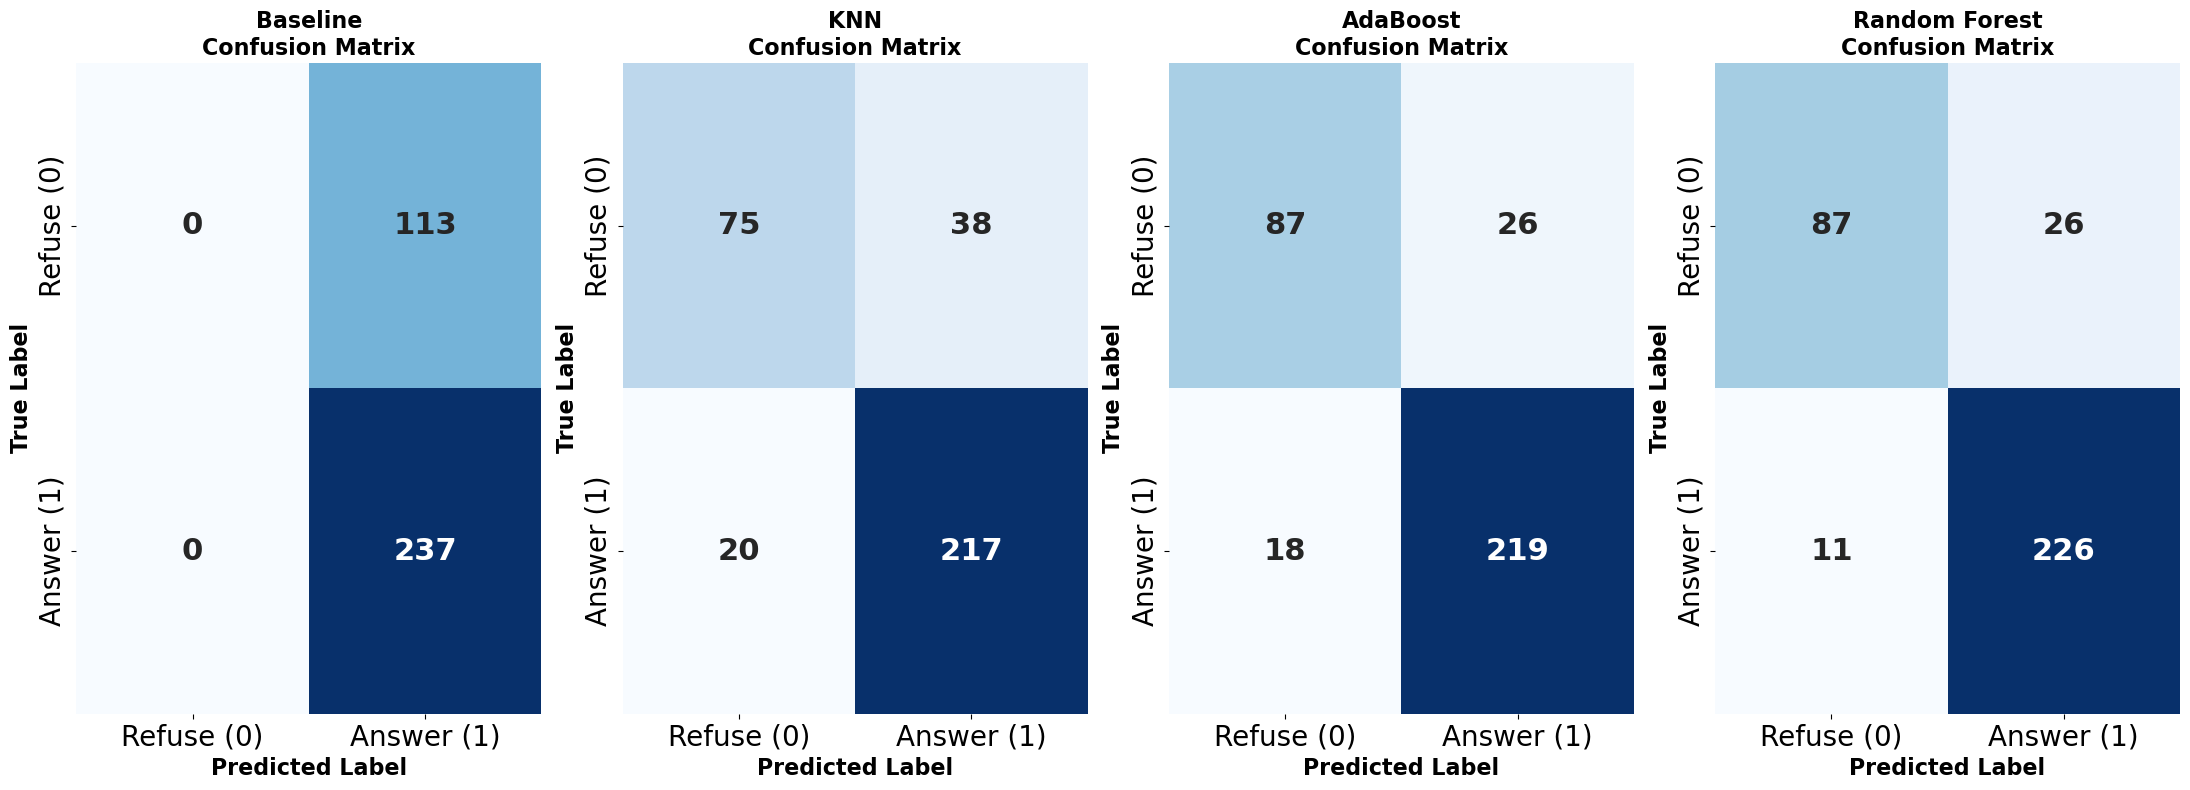

In [8]:
plot_confusion_matrices(final_models, X_test_processed, y_test)

# Confusion Matrix Analysis
### 1. False Positives (Predicting 1, True Label 0)

- The Mistake: The model predicts that the AI agent should use a tool, but in reality, no available tool is relevant.

- The Impact: The agent becomes over-eager and reckless. this is the most problematic mistake. The agent might send private user data to an irrelevant API, waste compute time and money on useless tool calls, or execute an unwanted action. Furthermore, it forces the agent to try and construct an answer from irrelevant data, leading directly to AI hallucinations instead of a safe refusal.

### 2. False Negatives (Predicting 0, True Label 1)

- The Mistake: The model predicts that the AI agent should refuse the prompt, but in reality, a relevant tool was perfectly available.

- The Impact: The agent becomes overly cautious and unhelpful. The AI will refuse to fulfill a valid user request leading to inaccuracy and a frustrating user experience, simply because it incorrectly determined its tools were inadequate.

### F1-score:
F1-score is the most appropriate primary metric to use here due to the clear class imbalance observed in the dataset (see Plot 1 in notebook 01). While other metrics offer targeted insights into specific performance dimensions like: minimizing false alarms, the F1-score provides the most reliable overall measure of the model's predictive balance by penalizing both false positives and false negatives.

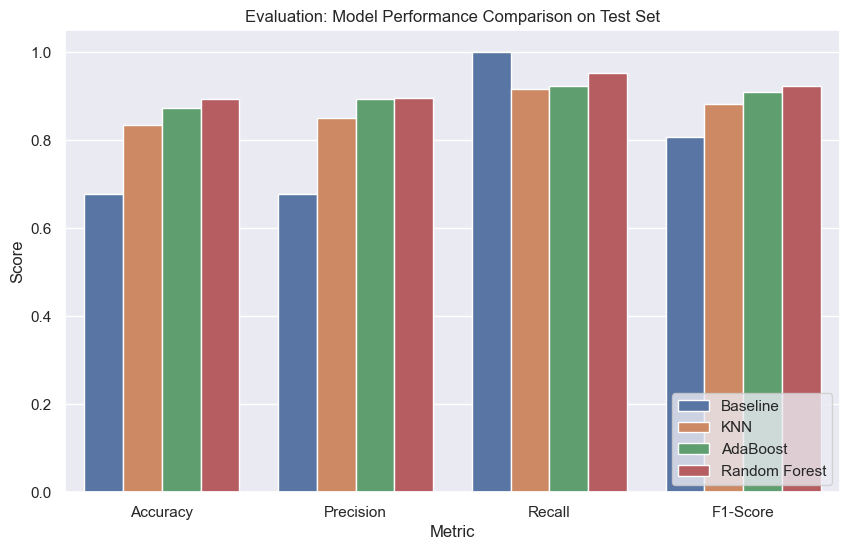

In [9]:
plot_metric_comparison(metrics_df)

#### 1. Baseline

The Baseline model predicted can_answer = 1 for every task because it strictly guesses the majority class. The fact that it achieved a ~0.80 F1-score without learning any actual patterns perfectly illustrates the danger of our dataset's severe class imbalance. It proves why accuracy alone as deceptive metric for this specific problem.

#### 2. K-Nearest Neighbors (KNN)

KNN yielded the poorest performance among the trained models. This is primarily due to the  our dataset; it expanded to 48 columns after one-hot encoding, which mathematically dilutes the significance of distance calculations between data points. Furthermore, KNN must calculate distances against the entire training set for every single new prediction. This introduces high inference latency, making it structurally unfit for a real-time AI agent that requires split-second routing decisions.

#### 3. AdaBoost

AdaBoost performed exceedingly well. As an ensemble tree-based model, it excels at finding strict thresholds to cleanly divide the data. More importantly, tree models perform intrinsic feature selection. Rather than treating all 48 columns equally (like KNN does), AdaBoost zeroes in on the most efficient, high-signal features and naturally filters out the noise from the less relevant categorical data.

#### 4. Random Forest

Random Forest achieved the best overall performance, though it was structurally very similar to AdaBoost. It thrived for the exact same reasons: intrinsic feature selection and robust handling of non-linear thresholds. While Random Forest produced the best metrics, in a real-world production environment, we would need to weigh its slight performance bump against the heavier memory and computational costs required to store and query a massive forest of deep trees.

### Discussion: Aggressive vs. Conservative Deployment

When deploying an AI agent, I strongly prefer a conservative model (one that prioritizes Precision and minimizes False Positives) over an aggressive one.

An aggressive model leans toward using tools whenever possible. While this might occasionally answer a tricky prompt, the risks are severe. False positives mean the agent is attempting to use irrelevant tools, which injects unwanted noise into the prompt and forces the AI to construct an answer from bad data—directly causing hallucinations. Even worse, an aggressive model risks leaking private client information to unnecessary APIs or executing unwanted actions.

While a conservative model might occasionally frustrate a user by refusing a valid request (a False Negative), it operates on a "fail-safe" principle. I prefer a model that explicitly refuses or throws a warning when it lacks the proper tools. Because end-users often place immense, unquestioning trust in AI outputs, prioritizing safety and accuracy over eagerness is paramount to preventing drastic real-world consequences.